In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "DesyneMartinez"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments//HW2")

## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 9, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis
The purpose of this analysis is to investigate the pour consistency at the bar's main tap station to get it up to par with the target pour volume of 16 ounces. The tap station is having liquid creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour named in the complaint data for many consumers going to the bar.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.
The quality characteristic we will monitor is the Pour Consistency at the tap station. This is measured in ounces and is a continuous variable with numeric data.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

Given the scenario a CUSUM and EWMA chart would be appropriate to use since we are analyzing a small sustained drift in the CO2 regulator when it comes to pour consistency. These Charts are designed to catch small shifts in the process mean and draws on the entire sequence of points rather than just the latest one. The CUSUM chart does have some tradeoffs because it is a complex chart to interpret while also being less obvious on how to set the control parameters, H  and K. For the sake of interpretability the EWMA chart utilizes weights to the observations themselves to produce a moving average making it much more simpler to implement and interpret than the CUSUM chart for this case.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [9]:
## Q4 Code ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages( "qcc")

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Data ##

BSPhase1_df <- read_excel("BustersSportsBar_PhaseI.xlsx")

## Data Integrity Check ##

BSPhase1_df |>
  glimpse()

#We are asked to estimate the standard deviation using the range method and get the subgroup means.

range(BSPhase1_df$Shift, na.rm = FALSE, finite = FALSE)

## Estimate process mean ##

mu0 <- mean(BSPhase1_df$Shift)

## Estimate process standard deviation ##

sigma_hat <- sd(BSPhase1_df$Shift)

cat(" Process mean:", mu0, "\n")
cat(" Process Standard Deviation:", sigma_hat, "\n")

summary(BSPhase1_df$Shift)






Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


[1]  1 25

 Process mean: 13 
 Process Standard Deviation: 7.359801 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       7      13      13      19      25 

The process mean is estimated to be $13$.

The Process Standard Deviation is estimated to be $7.36$.

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

[1] 19


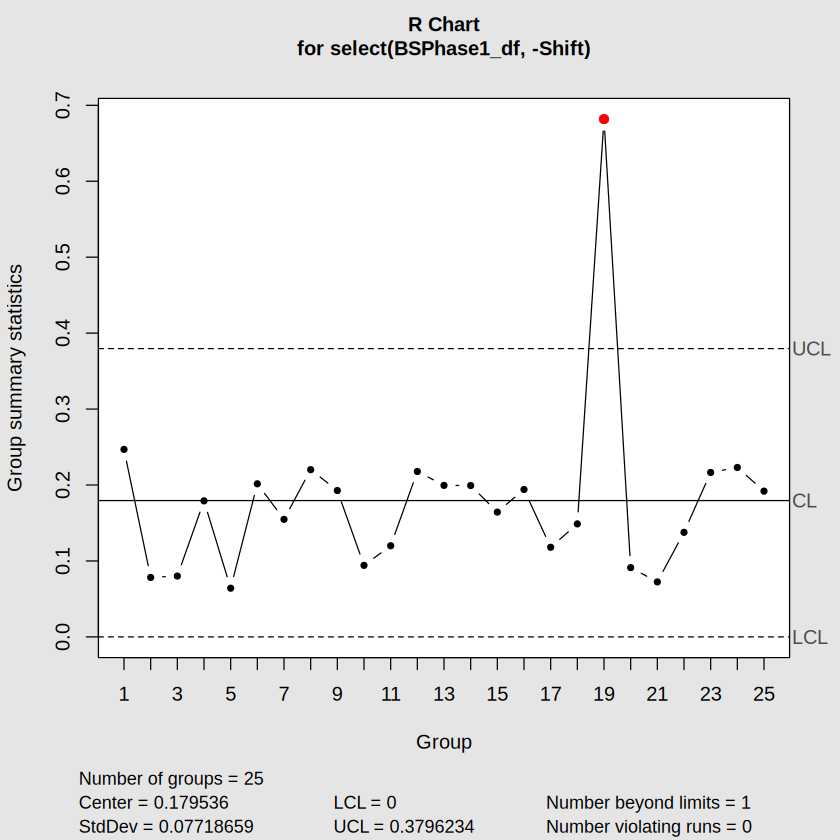

List of 11
 $ call      : language qcc(data = select(newphase1, -Shift), type = "R", plot = TRUE)
 $ type      : chr "R"
 $ data.name : chr "select(newphase1, -Shift)"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 0.2469 0.0783 0.0801 0.1791 0.0641 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.159
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.335
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

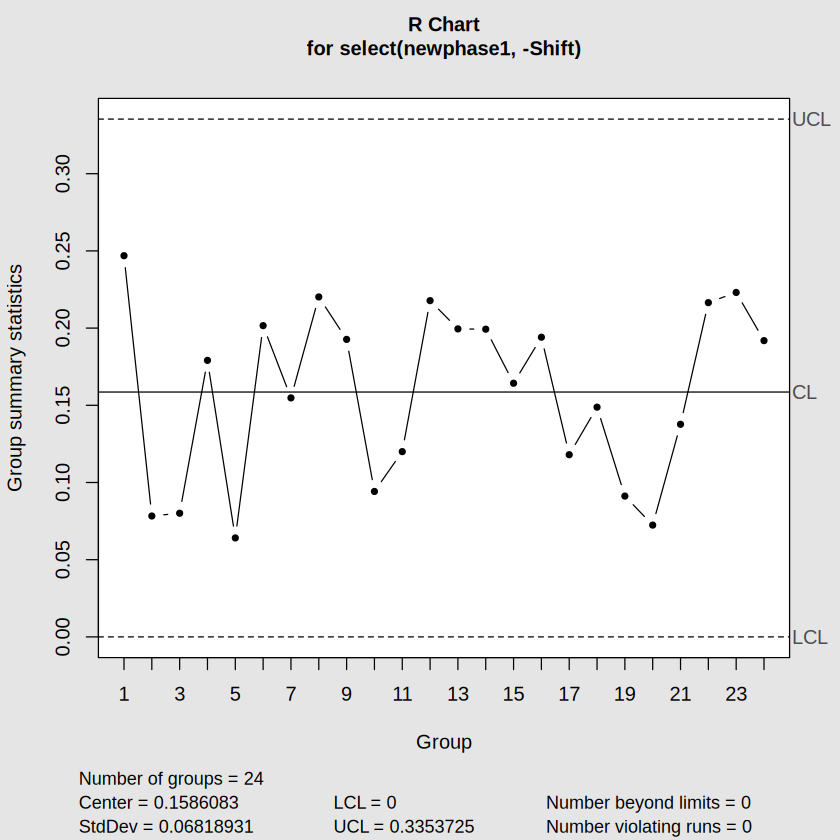

In [6]:
## Q5 Code ##

#Generating the Phase1 R chart
phase1_r <- qcc(BSPhase1_df |> select(-`Shift`),
                 type = "R",
                 plot = TRUE)

ooc_indices <- phase1_r$violations$beyond.limits
print(ooc_indices)

cleanphase1 <- setdiff(1:nrow(BSPhase1_df), ooc_indices)
newphase1 <- BSPhase1_df[cleanphase1, ]

phase1_Rnew <- qcc(newphase1 |> select(-`Shift`),
                 type = "R",
                 plot = TRUE)
                 (phase1_Rnew)


After generating the R chart it showcased to not have statistical control. As we inspected the chart subgroup number 19 showed to be beyond the upper control limit. This may lead to evidence that the CO2 regulator may be overpouring. By removing subgroup 19 the R chart showcased no other groups exceeding or below the respective limits which alerts us to possible statistical control! With this information we can proceed by constructing the X bar chart with these subgroups retained.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

List of 11
 $ call      : language qcc(data = select(newphase1, -Shift), type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "select(newphase1, -Shift)"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

[1] 12


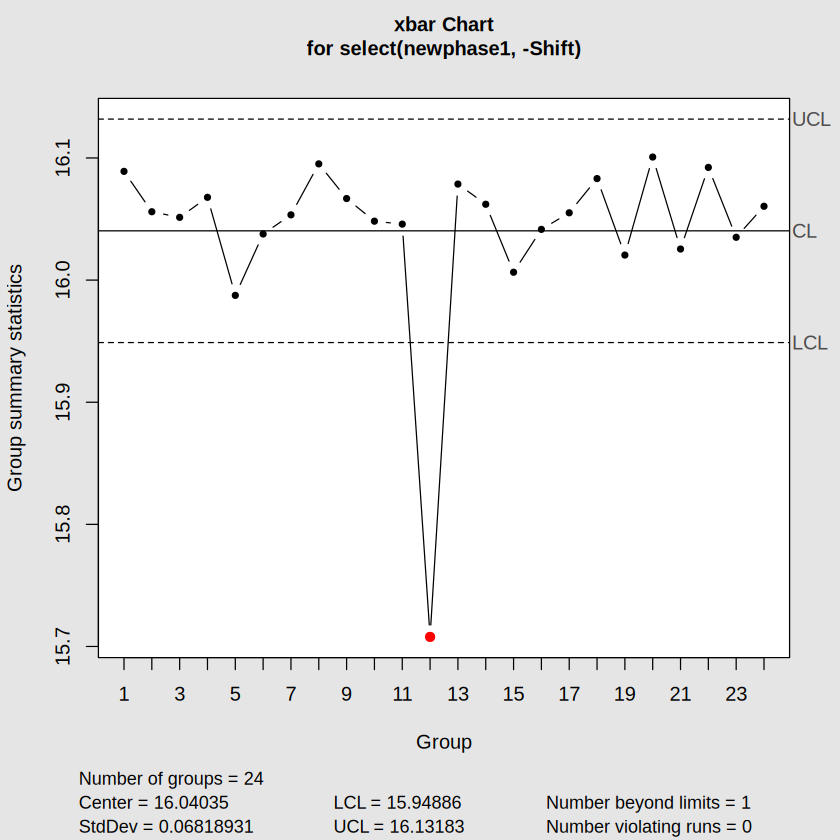

List of 11
 $ call      : language qcc(data = select(newphase1x, -Shift), type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "select(newphase1x, -Shift)"
 $ data      : num [1:23, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:23] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes     : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16.1
 $ std.dev   : num 0.0762
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.2
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

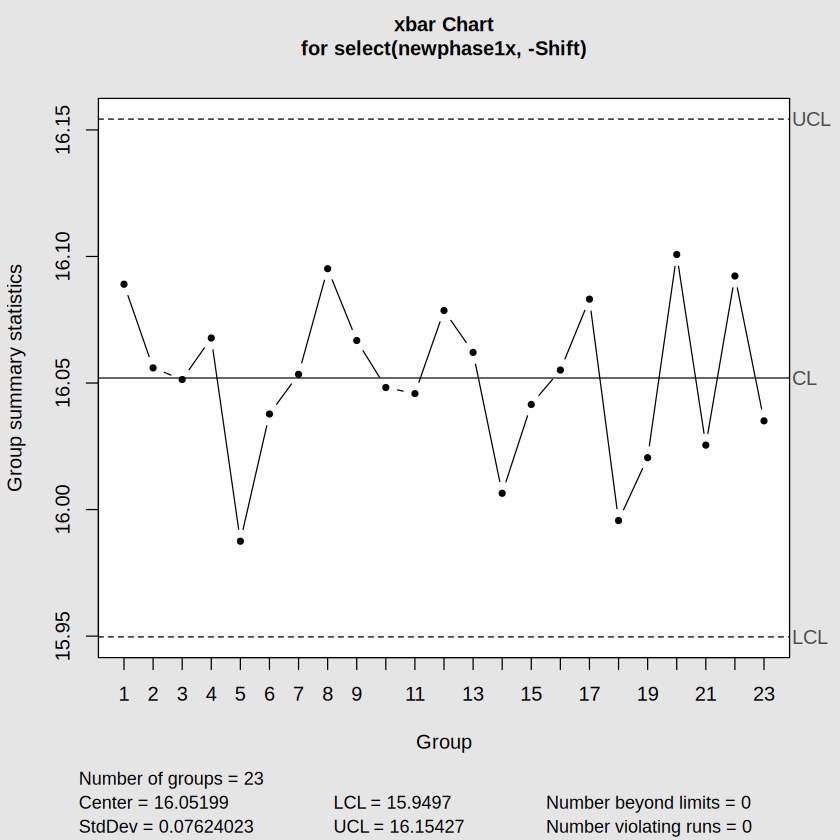

In [7]:
## Q6 Code ##

#New data

phase1_x <- qcc(newphase1 |> select(-`Shift`),
                 type = "xbar",
                 plot = TRUE)
                 (phase1_x)

ooc_indices_X <- phase1_x$violations$beyond.limits
print(ooc_indices_X)

cleanphase2 <- setdiff(1:nrow(newphase1), ooc_indices_X)
newphase1x <- BSPhase1_df[cleanphase2, ]

phase1_Xnew <- qcc(newphase1x |> select(-`Shift`),
                 type = "xbar",
                 plot = TRUE)
                 (phase1_Xnew)

Generating the new X bar chart with the subgroups retained from our analysis with the R chart showed that there was not complete evidence of statistical control just yet. The chart showed that subgroup 12 well exceeded the lower control limit straying further away from the desired center of 16 ounces for pour consistency. The charts have differing results based on the subgroups, but since the general manager is noticing that the CO2 regulator is slighltly under pouring the X bar chart gives evidence that the main defective issue of the regulator is that it is under pouring below the target mean of 16 oz per drink. Once removing this OOC subgroup we were able to achieve statistical control with no groups beyond or below the limits and no violating runs.

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

FNC: 1 

Process Capability Analysis

Call:
process.capability(object = phase1_Xnew, spec.limits = c(15.8,     16.2), target = 16, std.dev = phase1_Xnew$std.dev, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.07624         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.8744  0.7610  0.9877
Cp_l  1.1017  0.9713  1.2322
Cp_u  0.6471  0.5601  0.7342
Cp_k  0.6471  0.5434  0.7509
Cpm   0.7225  0.6154  0.8293

Exp<LSL 0.047%	 Obs<LSL 0.87%
Exp>USL 2.6%	 Obs>USL 3.5%


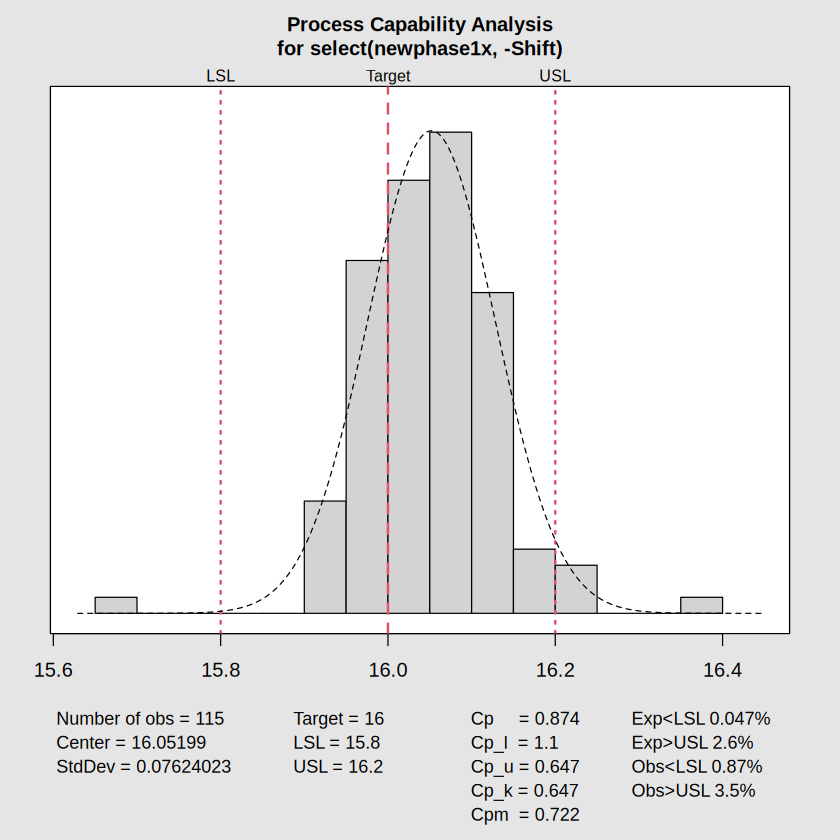

In [8]:
## Q7 Code ##

## Estimating Process Capability ##

FNC <- pnorm(1,mean=phase1_Xnew$center,
      sd=phase1_Xnew$std.dev) +
pnorm(2,mean=phase1_Xnew$center,sd=phase1_Xnew$std.dev,
      lower.tail=FALSE)

cat("FNC:", FNC, "\n")

process.capability(phase1_Xnew,
                   spec.limits=c(15.8,16.2),
                   target=16.00,
                   std.dev=phase1_Xnew$std.dev,
                   nsigmas=3)

## Cp ##
 - $CP$ = .874, which means that the difference between USL & LSL is .874 times the difference between UCL & LCL. This is not a good sign and more evidence is shown with how the histogram is not well centered.

## FNC ##
- From the chart, $Exp<LSL$ + $Exp>USL$ = >1 This is not a very good detail because it represents a tremendous chance of nonconforming units being developed. ##

## Cpk ##

- From the chart, we can see that $Cpk$ is .647, which is also not great detailing that the process is potentially not capable since the value is greater less than 1 and the histogram is not centered.

## Cpm ##

- The Cpm = .722 which is .075 points higher than the Cpk, Although it is higher it still is consistent with the other metrics that the process is incapable.

Overall all of the evidence points toward the process being incapable and with a higher chance of defective units being developed which in this context would be slighlty lower pour consistency for each drink.

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

(a). The Cusum Slack value K will be 0.5 and the decision interval H will be 5.

(b). The EWMA smoothing constant lambda = .05 and L = 2.615

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Rows: 20
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0792, 16.0338, 16.0122, 16.0267, 16.0398, 16.0597, 16.0523, 1…
$ Pour2 <dbl> 16.1017, 16.0037, 16.0499, 16.0925, 16.1340, 16.1104, 16.0450, 1…
$ Pour3 <dbl> 16.1325, 16.0427, 16.1096, 15.8856, 16.0590, 16.0148, 16.0159, 1…
$ Pour4 <dbl> 16.0593, 15.9930, 16.0066, 16.1227, 16.1007, 15.9631, 16.0345, 1…
$ Pour5 <dbl> 16.0851, 16.0053, 16.0047, 15.9553, 16.0776, 16.1903, 16.0249, 1…


List of 14
 $ call             : language cusum(data = BSPhase2_df, sizes = 5, center = mu02, decision.interval = h,      se.shift = k * 2, plot = T, sigma = sigma_hatX)
 $ type             : chr "cusum"
 $ data.name        : chr "BSPhase2_df"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 12.5
 $ std.dev          : num 2.84
 $ pos              : num [1:20] 0.331 0.744 1.302 1.978 2.829 ...
 $ neg              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

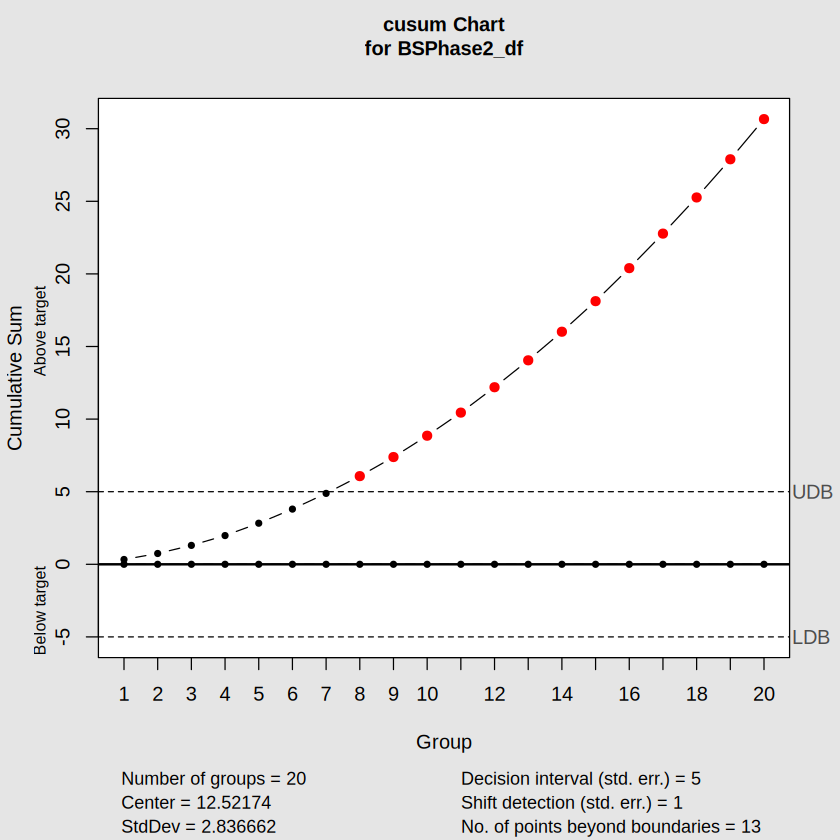

In [18]:
## Q9 Code ##
## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Data ##

BSPhase2_df <- read_excel("BustersSportsBar_PhaseII.xlsx")

## Data Integrity Check ##

BSPhase2_df |>
  glimpse()
mu02 <- mean(newphase1x$Shift)

## Estimate process standard deviation ##

sigma_hatX <- sd(newphase1x$Shift)

k <- 0.5
h <- 5

cusum(BSPhase2_df,sizes=5,center=mu02,sigma=sigma_hatX,se.shift=k*2,
      decision.interval = h,plot=T)









### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Rows: 20
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0792, 16.0338, 16.0122, 16.0267, 16.0398, 16.0597, 16.0523, 1…
$ Pour2 <dbl> 16.1017, 16.0037, 16.0499, 16.0925, 16.1340, 16.1104, 16.0450, 1…
$ Pour3 <dbl> 16.1325, 16.0427, 16.1096, 15.8856, 16.0590, 16.0148, 16.0159, 1…
$ Pour4 <dbl> 16.0593, 15.9930, 16.0066, 16.1227, 16.1007, 15.9631, 16.0345, 1…
$ Pour5 <dbl> 16.0851, 16.0053, 16.0047, 15.9553, 16.0776, 16.1903, 16.0249, 1…


List of 11
 $ call      : language qcc(data = select(BSPhase2_df, -Shift), type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "select(BSPhase2_df, -Shift)"
 $ data      : num [1:20, 1:5] 16.1 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 16.1 16 16 16 16.1 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.0602
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

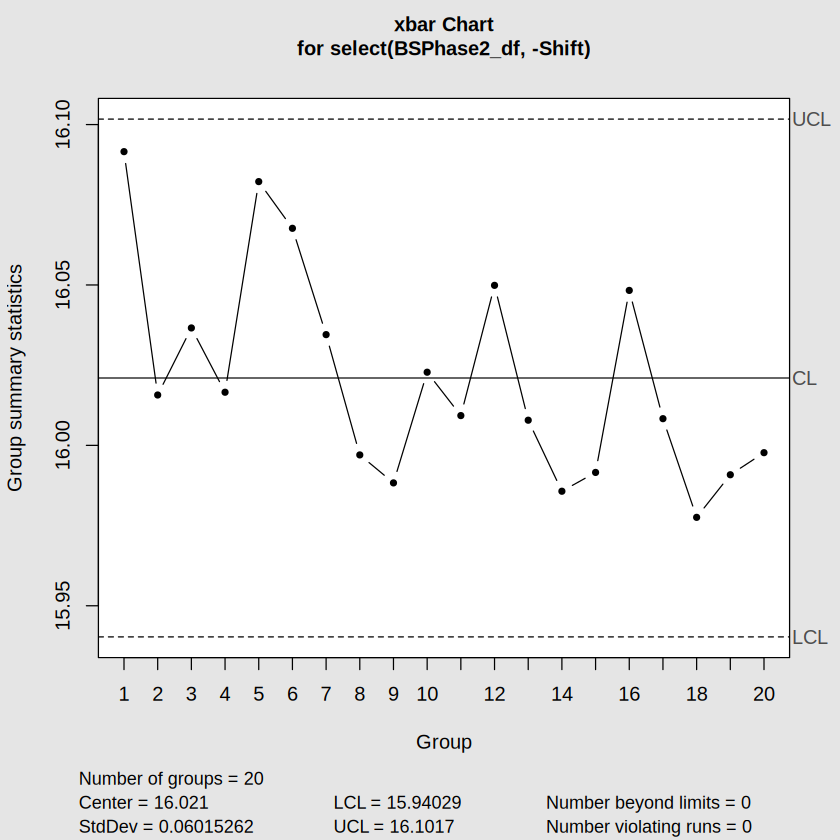

List of 15
 $ call      : language ewma(data = BSPhase2_df, center = 16, lambda = 0.05, nsigmas = 2.615, sigma = sigma_hatX)
 $ type      : chr "ewma"
 $ data.name : chr "BSPhase2_df"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16
 $ std.dev   : num 2.6
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.9 15.8 15.7 15.6 15.5 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.0532 0.0733 0.0876 0.0988 0.1078 ...
 $ lambda    : num 0.05
 $ nsigmas   : num 2.62
 $ limits    : num [1:20, 1:2] 15.9 15.8 15.8 15.7 15.7 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:18] 2 3 4 5 6 7 8 9 10 11 ...
  ..- attr(*, "names")= chr [1:18] "2" "3" "4" "5" ...
 - attr(*, "class")= chr "

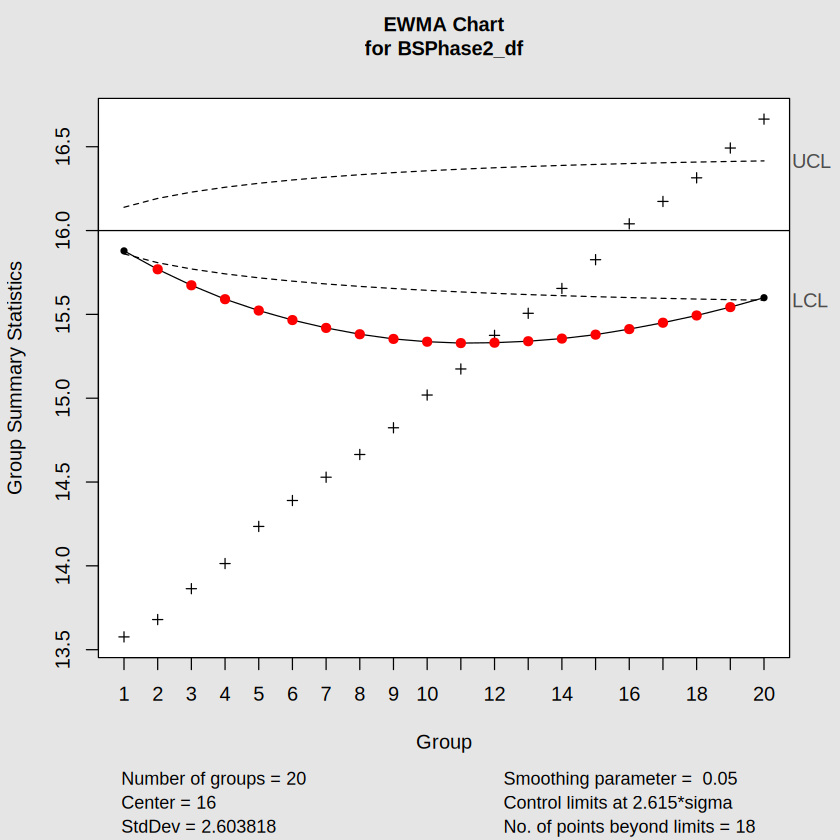

In [12]:
## Q10 Code ##

## Data Integrity Check ##

BSPhase2_df |>
  glimpse()

phase2_x <- qcc(BSPhase2_df |> select(-`Shift`),
                 type = "xbar",
                 plot = TRUE)
                 (phase2_x)



ewma(BSPhase2_df,center=16,sigma=sigma_hatX,lambda=0.05,nsigmas=2.615)

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

List of 14
 $ call             : language cusum(data = BSPhase2_df, sizes = 5, center = mu0, decision.interval = h,      se.shift = k * 2, plot = T)
 $ type             : chr "cusum"
 $ data.name        : chr "BSPhase2_df"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16
 $ std.dev          : num 2.84
 $ pos              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ neg              : num [1:20] -1.41 -2.74 -3.92 -4.99 -5.88 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

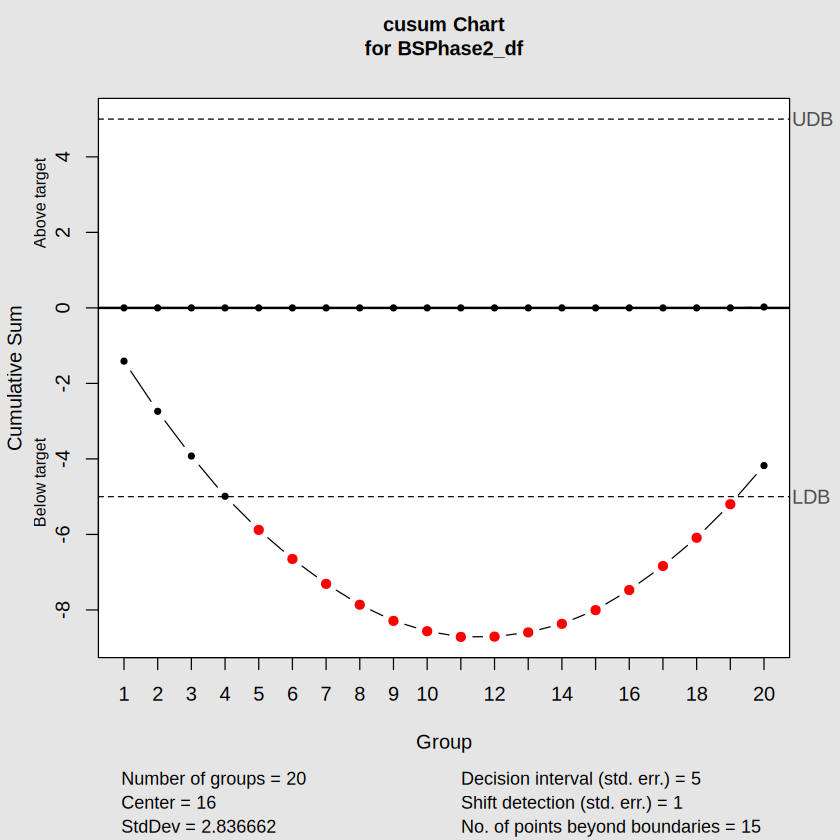

List of 15
 $ call      : language ewma(data = BSPhase2_df, center = 16, lambda = 0.2, nsigmas = 2.962)
 $ type      : chr "ewma"
 $ data.name : chr "BSPhase2_df"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16
 $ std.dev   : num 2.6
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.5 15.1 14.9 14.7 14.6 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.213 0.272 0.304 0.323 0.335 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:20, 1:2] 15.4 15.2 15.1 15 15 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:11] 2 3 4 5 6 7 8 9 10 11 ...
  ..- attr(*, "names")= chr [1:11] "2" "3" "4" "5" ...
 - attr(*, "class")= chr "ewma.qcc"

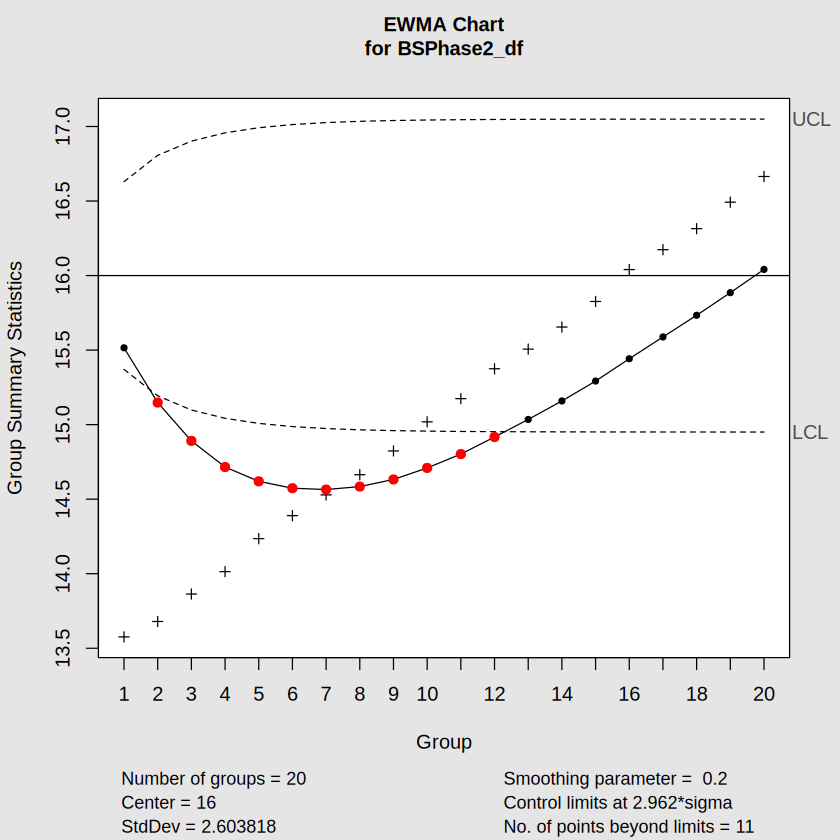

In [ ]:
## Q11 Code ##


cusum(BSPhase2_df,sizes=5,center=mu0,se.shift=k*2,
      decision.interval = h,plot=T)

ewma(BSPhase2_df,center=16,lambda=0.2,nsigmas=2.962)

### Q12: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?